In [1]:
import sys
print(sys.executable)

E:\proekt3\practika_leto\venv-flower-sim\Scripts\python.exe


In [2]:
%pip install "flwr[simulation]" torch torchvision

  Using cached torch-2.13.0-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Using cached torchvision-0.28.0-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached flwr-1.32.1-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached grpcio-1.83.0-cp311-cp311-win_amd64.whl.metadata (3.8 kB)
  Using cached grpcio_health_checking-1.83.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached cryptography-46.0.7-cp311-abi3-win_amd64.whl.metadata (5.7 kB)
  Using cached pycryptodome-3.23.0-cp37-abi3-win_amd64.whl.metadata (3.5 kB)
  Using cached iterators-0.0.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached typer-0.20.1-py3-none-any.whl.metadata (16 kB)
  Using cached uv-0.11.32-py3-none-win_amd64.whl.metadata (11 kB)
  Using cached tomli-2.4.1-cp311-cp311-win_amd64.whl.metadata (10 kB)
  Using cached tomli_w-1.2.0-py3-none-any.whl.metadata (5.7 kB)
  Usin


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys, importlib.metadata as md
print("Executable:", sys.executable)
import flwr, ray, torch, torchvision
print("flwr:", flwr.__version__)
print("ray:", ray.__version__)
print("torch:", torch.__version__)
print("numpy:", md.version("numpy"))

Executable: E:\proekt3\practika_leto\venv-flower-sim\Scripts\python.exe


2026-07-24 12:50:30,483	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


flwr: 1.32.1
ray: 2.55.1
torch: 2.13.0+cpu
numpy: 2.4.6


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from collections import OrderedDict

from flwr.client import ClientApp, NumPyClient
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.common import Context, ndarrays_to_parameters
from flwr.simulation import run_simulation

NUM_CLIENTS = 3
NUM_ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
N_TRAIN_PER_CLIENT = 4000
DEVICE = torch.device("cpu")

torch.manual_seed(0)
np.random.seed(0)
print("Параметры заданы")

Параметры заданы


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

def make_client_loaders(client_id):
    g = torch.Generator().manual_seed(42)
    all_idx = torch.randperm(len(train_set), generator=g).tolist()
    per = len(all_idx) // NUM_CLIENTS
    idx = all_idx[client_id * per:(client_id + 1) * per][:N_TRAIN_PER_CLIENT]
    train_loader = DataLoader(Subset(train_set, idx), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=256)
    return train_loader, test_loader

print("Клиент 0 получил", len(make_client_loaders(0)[0].dataset), "картинок")

Клиент 0 получил 4000 картинок


In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

print("Выходов у модели:", Net().fc2.out_features)

Выходов у модели: 10


In [5]:
def train(net, loader, epochs):
    net.train()
    opt = torch.optim.Adam(net.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x, y in loader:
            opt.zero_grad()
            loss = crit(net(x), y)
            loss.backward()
            opt.step()

def test(net, loader):
    net.eval()
    crit = nn.CrossEntropyLoss()
    loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            out = net(x)
            loss += crit(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss / total, correct / total

def get_parameters(net):
    return [v.cpu().numpy() for v in net.state_dict().values()]

def set_parameters(net, parameters):
    sd = OrderedDict({k: torch.tensor(v) for k, v in zip(net.state_dict().keys(), parameters)})
    net.load_state_dict(sd, strict=True)

print("Функции готовы")

Функции готовы


In [6]:
class FlowerClient(NumPyClient):
    def __init__(self, net, train_loader, test_loader):
        self.net, self.train_loader, self.test_loader = net, train_loader, test_loader
    def fit(self, parameters, config):
        set_parameters(self.net, parameters)
        train(self.net, self.train_loader, LOCAL_EPOCHS)
        return get_parameters(self.net), len(self.train_loader.dataset), {}
    def evaluate(self, parameters, config):
        set_parameters(self.net, parameters)
        loss, acc = test(self.net, self.test_loader)
        return loss, len(self.test_loader.dataset), {"accuracy": acc}

def client_fn(context: Context):
    cid = context.node_config["partition-id"]
    net = Net().to(DEVICE)
    tl, vl = make_client_loaders(cid)
    return FlowerClient(net, tl, vl).to_client()

client_app = ClientApp(client_fn=client_fn)
print("ClientApp готов")

ClientApp готов


In [7]:
round_accuracy = []

def weighted_average(metrics):
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    round_accuracy.append(acc)
    print(f"  >>> Раунд {len(round_accuracy)}: accuracy = {acc * 100:.2f}%")
    return {"accuracy": acc}

def server_fn(context: Context):
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_available_clients=NUM_CLIENTS,
        evaluate_metrics_aggregation_fn=weighted_average,
        initial_parameters=ndarrays_to_parameters(get_parameters(Net())),
    )
    return ServerAppComponents(strategy=strategy, config=ServerConfig(num_rounds=NUM_ROUNDS))

server_app = ServerApp(server_fn=server_fn)
print("ServerApp и FedAvg готовы")

ServerApp и FedAvg готовы


In [8]:
round_accuracy.clear()
run_simulation(
    server_app=server_app,
    client_app=client_app,
    num_supernodes=NUM_CLIENTS,
    backend_config={"client_resources": {"num_cpus": 1, "num_gpus": 0}},
)
print("\nИтоговая accuracy по раундам:", [round(a * 100, 2) for a in round_accuracy])


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=5, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(raylet) Stack (most recent call first):
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\work

  >>> Раунд 1: accuracy = 87.08%


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


  >>> Раунд 2: accuracy = 95.72%


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

  >>> Раунд 4: accuracy = 97.63%


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 119.51s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.3983482505083084
INFO :      		round 2: 0.14359590512216092
INFO :      		round 3: 0.10160858246833086
INFO :      		round 4: 0.07760801516287029
INFO :      		round 5: 0.06440270661525428
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.8708), (2, 0.9572), (3, 0.9689), (4, 0.9763), (5, 0.9785)]}
INFO :      


  >>> Раунд 5: accuracy = 97.85%


(ClientAppActor pid=24020) WARNING :   Manually terminating ClientAppActor
(raylet) Stack (most recent call first): [repeated 7x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config [repeated 7x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect [repeated 7x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown [repeated 6x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\client_mode_hook.py", line 107 in wrapper [repeated 15x across cluster]



Итоговая accuracy по раундам: [87.08, 95.72, 96.89, 97.63, 97.85]


In [9]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


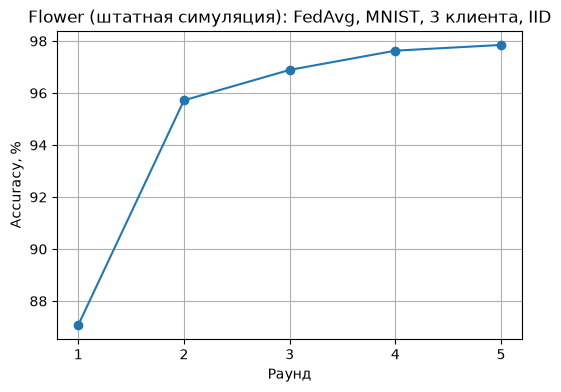

Сохранено: flower_sim_accuracy.png и flower_sim_accuracy.csv


In [10]:
import matplotlib.pyplot as plt
import csv

acc = [a * 100 for a in round_accuracy]
rounds = list(range(1, len(acc) + 1))

with open("flower_sim_accuracy.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["round", "accuracy_percent"])
    for r, a in zip(rounds, acc):
        w.writerow([r, f"{a:.2f}"])

plt.figure(figsize=(6, 4))
plt.plot(rounds, acc, marker="o")
plt.xlabel("Раунд")
plt.ylabel("Accuracy, %")
plt.title("Flower (штатная симуляция): FedAvg, MNIST, 3 клиента, IID")
plt.xticks(rounds)
plt.grid(True)
plt.savefig("flower_sim_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: flower_sim_accuracy.png и flower_sim_accuracy.csv")

In [11]:
%pip install opacus

  Using cached opacus-1.6.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
Using cached opacus-1.6.0-py3-none-any.whl (308 kB)
Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import opacus
print("opacus:", opacus.__version__)

opacus: 1.6.0


In [13]:
import math, warnings
from opacus import PrivacyEngine
from opacus.accountants import RDPAccountant
warnings.filterwarnings("ignore")

NOISE_MULTIPLIER = 1.1   # уровень шума (больше -> приватнее, но ниже точность)
MAX_GRAD_NORM    = 1.0   # порог клиппинга градиента каждого примера
DELTA            = 1e-5  # δ: допустимая вероятность нарушения гарантии
print("Параметры DP заданы")

Параметры DP заданы


In [14]:
def dp_train(net, loader):
    net.train()
    opt = torch.optim.Adam(net.parameters(), lr=0.001)
    pe = PrivacyEngine(secure_mode=False)
    priv_net, priv_opt, priv_loader = pe.make_private(
        module=net, optimizer=opt, data_loader=loader,
        noise_multiplier=NOISE_MULTIPLIER, max_grad_norm=MAX_GRAD_NORM,
    )
    crit = nn.CrossEntropyLoss()
    for _ in range(LOCAL_EPOCHS):
        for x, y in priv_loader:
            priv_opt.zero_grad()
            loss = crit(priv_net(x.to(DEVICE)), y.to(DEVICE))
            loss.backward()
            priv_opt.step()
    # наружу отдаём РАЗВЁРНУТЫЕ веса (без opacus-обёртки)
    return [v.cpu().numpy() for v in priv_net._module.state_dict().values()]

class DPFlowerClient(NumPyClient):
    def __init__(self, tl, vl):
        self.tl, self.vl = tl, vl
    def fit(self, parameters, config):
        net = Net().to(DEVICE)
        set_parameters(net, parameters)
        return dp_train(net, self.tl), len(self.tl.dataset), {}
    def evaluate(self, parameters, config):
        net = Net().to(DEVICE)
        set_parameters(net, parameters)
        loss, acc = test(net, self.vl)
        return loss, len(self.vl.dataset), {"accuracy": acc}

def dp_client_fn(context: Context):
    cid = context.node_config["partition-id"]
    tl, vl = make_client_loaders(cid)
    return DPFlowerClient(tl, vl).to_client()

dp_client_app = ClientApp(client_fn=dp_client_fn)

dp_round_accuracy = []
def dp_weighted_average(metrics):
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    dp_round_accuracy.append(acc)
    print(f"  >>> [DP] Раунд {len(dp_round_accuracy)}: accuracy = {acc * 100:.2f}%")
    return {"accuracy": acc}

def dp_server_fn(context: Context):
    strategy = FedAvg(
        fraction_fit=1.0, fraction_evaluate=1.0, min_available_clients=NUM_CLIENTS,
        evaluate_metrics_aggregation_fn=dp_weighted_average,
        initial_parameters=ndarrays_to_parameters(get_parameters(Net())),
    )
    return ServerAppComponents(strategy=strategy, config=ServerConfig(num_rounds=NUM_ROUNDS))

dp_server_app = ServerApp(server_fn=dp_server_fn)
print("DP-клиент и сервер готовы")

DP-клиент и сервер готовы


In [15]:
dp_round_accuracy.clear()
run_simulation(
    server_app=dp_server_app,
    client_app=dp_client_app,
    num_supernodes=NUM_CLIENTS,
    backend_config={"client_resources": {"num_cpus": 1, "num_gpus": 0}},
)

# честный подсчёт бюджета приватности по RDP-аккаунтингу
steps_per_epoch = math.ceil(N_TRAIN_PER_CLIENT / BATCH_SIZE)
sample_rate = BATCH_SIZE / N_TRAIN_PER_CLIENT

def eps_for(steps):
    acc = RDPAccountant()
    for _ in range(steps):
        acc.step(noise_multiplier=NOISE_MULTIPLIER, sample_rate=sample_rate)
    return acc.get_epsilon(delta=DELTA)

eps_round = eps_for(steps_per_epoch)                       # за один раунд
eps_total = eps_for(NUM_ROUNDS * LOCAL_EPOCHS * steps_per_epoch)  # за всё обучение

print("\nAccuracy с DP по раундам:", [round(a * 100, 2) for a in dp_round_accuracy])
print("Accuracy без DP (база):   ", [round(a * 100, 2) for a in round_accuracy])
print(f"\nБюджет приватности на клиента: ε за 1 раунд ≈ {eps_round:.2f}, "
      f"ε за все {NUM_ROUNDS} раундов ≈ {eps_total:.2f} (δ = {DELTA})")


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=5, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
(raylet) Stack (most recent call first):
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdownWindows fatal exception: 
(raylet)   File "E:\proekt3\practika_leto\ve

  >>> [DP] Раунд 1: accuracy = 47.03%


(ClientAppActor pid=25360) E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on. [repeated 2x across cluster]
(ClientAppActor pid=25360)   warnings.warn( [repeated 2x across cluster]
(ClientAppActor pid=14904) C:\Users\nak\AppData\Local\Temp\ipykernel_15020\62088326.py:14: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details. [repeated 3x across cluster]
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate:

  >>> [DP] Раунд 2: accuracy = 59.68%


(ClientAppActor pid=22176) C:\Users\nak\AppData\Local\Temp\ipykernel_15020\62088326.py:14: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details. [repeated 3x across cluster]
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

  >>> [DP] Раунд 4: accuracy = 67.57%


(ClientAppActor pid=22176) C:\Users\nak\AppData\Local\Temp\ipykernel_15020\62088326.py:14: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details. [repeated 3x across cluster]
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 125.68s
INFO :      	History (loss, distributed):
INFO :      		round 1: 2.1333416954040527
INFO :      		round 2: 1.8028258459091187
INFO :      		round 3: 1.3536995170593262
INFO :      		round 4: 1.0273545325279236
INFO :      		round 5: 0.8318787575721741
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': 

  >>> [DP] Раунд 5: accuracy = 72.15%


(ClientAppActor pid=14904) C:\Users\nak\AppData\Local\Temp\ipykernel_15020\62088326.py:14: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details. [repeated 2x across cluster]



Accuracy с DP по раундам: [47.03, 59.68, 64.47, 67.57, 72.15]
Accuracy без DP (база):    [87.08, 95.72, 96.89, 97.63, 97.85]

Бюджет приватности на клиента: ε за 1 раунд ≈ 0.90, ε за все 5 раундов ≈ 1.18 (δ = 1e-05)


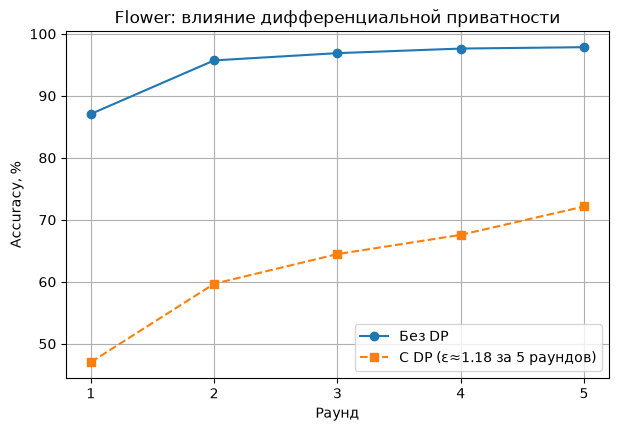

Сохранено: flower_dp_comparison.png, flower_dp_accuracy.csv


In [16]:
import csv
r = list(range(1, NUM_ROUNDS + 1))

plt.figure(figsize=(7, 4.5))
plt.plot(r, [a * 100 for a in round_accuracy], marker="o", label="Без DP")
plt.plot(r, [a * 100 for a in dp_round_accuracy], marker="s", linestyle="--",
         label=f"С DP (ε≈{eps_total:.2f} за 5 раундов)")
plt.xlabel("Раунд"); plt.ylabel("Accuracy, %")
plt.title("Flower: влияние дифференциальной приватности")
plt.xticks(r); plt.legend(); plt.grid(True)
plt.savefig("flower_dp_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

with open("flower_dp_accuracy.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["round", "acc_no_dp_%", "acc_dp_%"])
    for i in r:
        w.writerow([i, f"{round_accuracy[i-1]*100:.2f}", f"{dp_round_accuracy[i-1]*100:.2f}"])
    w.writerow([])
    w.writerow(["eps_per_round", f"{eps_round:.3f}"])
    w.writerow(["eps_total_5rounds", f"{eps_total:.3f}"])
    w.writerow(["delta", DELTA]); w.writerow(["noise_multiplier", NOISE_MULTIPLIER])
    w.writerow(["max_grad_norm", MAX_GRAD_NORM])
print("Сохранено: flower_dp_comparison.png, flower_dp_accuracy.csv")

эксперимент с неоднородными данными (non-IID):

In [17]:
CLASSES_PER_CLIENT = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

def make_noniid_loaders(client_id):
    labels = train_set.targets
    mask = torch.zeros(len(train_set), dtype=torch.bool)
    for c in CLASSES_PER_CLIENT[client_id]:
        mask |= (labels == c)
    idx = mask.nonzero(as_tuple=True)[0]
    g = torch.Generator().manual_seed(42)
    idx = idx[torch.randperm(len(idx), generator=g)][:N_TRAIN_PER_CLIENT].tolist()
    train_loader = DataLoader(Subset(train_set, idx), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=256)
    return train_loader, test_loader

print("Клиент 0 классы:", CLASSES_PER_CLIENT[0],
      "| картинок:", len(make_noniid_loaders(0)[0].dataset))

def noniid_client_fn(context: Context):
    cid = context.node_config["partition-id"]
    tl, vl = make_noniid_loaders(cid)
    return FlowerClient(Net().to(DEVICE), tl, vl).to_client()
noniid_client_app = ClientApp(client_fn=noniid_client_fn)

noniid_round_accuracy = []
def noniid_weighted_average(metrics):
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    noniid_round_accuracy.append(acc)
    print(f"  >>> [non-IID] Раунд {len(noniid_round_accuracy)}: accuracy = {acc * 100:.2f}%")
    return {"accuracy": acc}

def noniid_server_fn(context: Context):
    strategy = FedAvg(
        fraction_fit=1.0, fraction_evaluate=1.0, min_available_clients=NUM_CLIENTS,
        evaluate_metrics_aggregation_fn=noniid_weighted_average,
        initial_parameters=ndarrays_to_parameters(get_parameters(Net())),
    )
    return ServerAppComponents(strategy=strategy, config=ServerConfig(num_rounds=NUM_ROUNDS))
noniid_server_app = ServerApp(server_fn=noniid_server_fn)
print("non-IID клиент и сервер готовы")

Клиент 0 классы: [0, 1, 2] | картинок: 4000
non-IID клиент и сервер готовы


In [18]:
noniid_round_accuracy.clear()
run_simulation(
    server_app=noniid_server_app,
    client_app=noniid_client_app,
    num_supernodes=NUM_CLIENTS,
    backend_config={"client_resources": {"num_cpus": 1, "num_gpus": 0}},
)
print("\nAccuracy non-IID: ", [round(a * 100, 2) for a in noniid_round_accuracy])
print("Accuracy IID (база):", [round(a * 100, 2) for a in round_accuracy])


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=5, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
(raylet) Stack (most recent call first):
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-pa

  >>> [non-IID] Раунд 1: accuracy = 47.12%


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


  >>> [non-IID] Раунд 2: accuracy = 73.66%


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

  >>> [non-IID] Раунд 4: accuracy = 83.49%


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 90.22s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.471077822303772
INFO :      		round 2: 0.8462937523841858
INFO :      		round 3: 0.6056951889991761
INFO :      		round 4: 0.5158342250585556
INFO :      		round 5: 0.4312949390411377
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.4712), (2, 0.7366), (3, 0.8163), (4, 0.8349), (5, 0.8698)]}
INFO :      


  >>> [non-IID] Раунд 5: accuracy = 86.98%


(raylet) Stack (most recent call first): [repeated 7x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config [repeated 7x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect [repeated 7x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown [repeated 7x across cluster]
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\client_mode_hook.py", line 107 in wrapper [repeated 15x across cluster]



Accuracy non-IID:  [47.12, 73.66, 81.63, 83.49, 86.98]
Accuracy IID (база): [87.08, 95.72, 96.89, 97.63, 97.85]


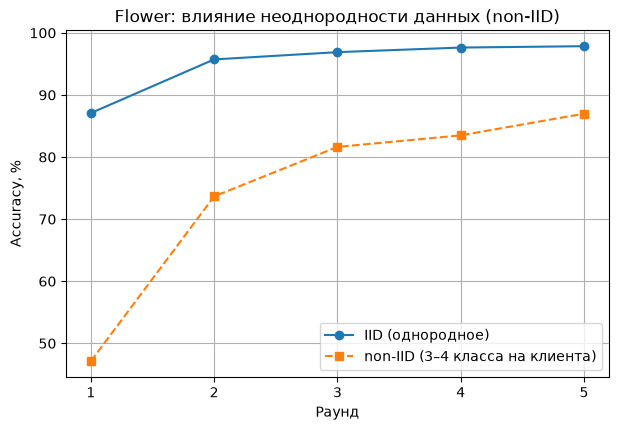

Сохранено: flower_noniid_comparison.png, flower_noniid_accuracy.csv


In [19]:
r = list(range(1, NUM_ROUNDS + 1))
plt.figure(figsize=(7, 4.5))
plt.plot(r, [a * 100 for a in round_accuracy], marker="o", label="IID (однородное)")
plt.plot(r, [a * 100 for a in noniid_round_accuracy], marker="s", linestyle="--",
         label="non-IID (3–4 класса на клиента)")
plt.xlabel("Раунд"); plt.ylabel("Accuracy, %")
plt.title("Flower: влияние неоднородности данных (non-IID)")
plt.xticks(r); plt.legend(); plt.grid(True)
plt.savefig("flower_noniid_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

with open("flower_noniid_accuracy.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["round", "acc_iid_%", "acc_noniid_%"])
    for i in r:
        w.writerow([i, f"{round_accuracy[i-1]*100:.2f}", f"{noniid_round_accuracy[i-1]*100:.2f}"])
print("Сохранено: flower_noniid_comparison.png, flower_noniid_accuracy.csv")

кастомная агрегация (медиана) + отравление на Flower :


In [20]:
from flwr.common import parameters_to_ndarrays

class FedMedianStrategy(FedAvg):
    """Замена FedAvg: покоординатная медиана вместо взвешенного среднего."""
    def aggregate_fit(self, server_round, results, failures):
        updates = [parameters_to_ndarrays(fr.parameters) for _, fr in results]
        median = [np.median(np.stack(layer), axis=0).astype(np.float32)
                  for layer in zip(*updates)]
        return ndarrays_to_parameters(median), {}

class PoisonClient(FlowerClient):
    """Отравитель: учится как обычный, но отправляет веса, умноженные на −5."""
    def fit(self, parameters, config):
        params, n, metrics = super().fit(parameters, config)
        return [(-5.0) * w for w in params], n, metrics

def run_experiment(agg="fedavg", poison=False):
    acc_hist = []
    def wavg(metrics):
        total = sum(n for n, _ in metrics)
        a = sum(n * m["accuracy"] for n, m in metrics) / total
        acc_hist.append(a)
        return {"accuracy": a}
    def cfn(context):
        cid = context.node_config["partition-id"]
        tl, vl = make_client_loaders(cid)                       # IID, как в базе
        cls = PoisonClient if (poison and cid == 0) else FlowerClient
        return cls(Net().to(DEVICE), tl, vl).to_client()
    capp = ClientApp(client_fn=cfn)
    Strat = FedMedianStrategy if agg == "median" else FedAvg
    def sfn(context):
        strategy = Strat(
            fraction_fit=1.0, fraction_evaluate=1.0, min_available_clients=NUM_CLIENTS,
            evaluate_metrics_aggregation_fn=wavg,
            initial_parameters=ndarrays_to_parameters(get_parameters(Net())),
        )
        return ServerAppComponents(strategy=strategy, config=ServerConfig(num_rounds=NUM_ROUNDS))
    sapp = ServerApp(server_fn=sfn)
    run_simulation(server_app=sapp, client_app=capp, num_supernodes=NUM_CLIENTS,
                   backend_config={"client_resources": {"num_cpus": 1, "num_gpus": 0}})
    return [round(a * 100, 2) for a in acc_hist]

print("Стратегия-медиана, отравитель и обёртка готовы")

Стратегия-медиана, отравитель и обёртка готовы


In [21]:
agg_results = {}
agg_results["FedAvg, без атаки"] = run_experiment("fedavg", poison=False)
agg_results["FedAvg, атака"]     = run_experiment("fedavg", poison=True)
agg_results["Median, без атаки"] = run_experiment("median", poison=False)
agg_results["Median, атака"]     = run_experiment("median", poison=True)

print("\n================ ИТОГИ ================")
for k, v in agg_results.items():
    print(f"{k:20s}: по раундам {v}  ->  итог {v[-1]}%")


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=5, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
(raylet) Stack (most recent call first):
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py"Windows fatal exception: access violation
(raylet) 
(raylet) , line 2801 in disconnect
(raylet)   File "E:\proekt3\practika_leto\venv-flower-sim\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)


================ ИТОГИ ================
FedAvg, без атаки   : по раундам [92.53, 96.23, 97.24, 97.53, 97.83]  ->  итог 97.83%
FedAvg, атака       : по раундам [10.48, 58.08, 14.95, 58.01, 48.33]  ->  итог 48.33%
Median, без атаки   : по раундам [91.8, 96.15, 97.18, 97.55, 98.01]  ->  итог 98.01%
Median, атака       : по раундам [84.02, 94.63, 96.23, 96.79, 97.14]  ->  итог 97.14%


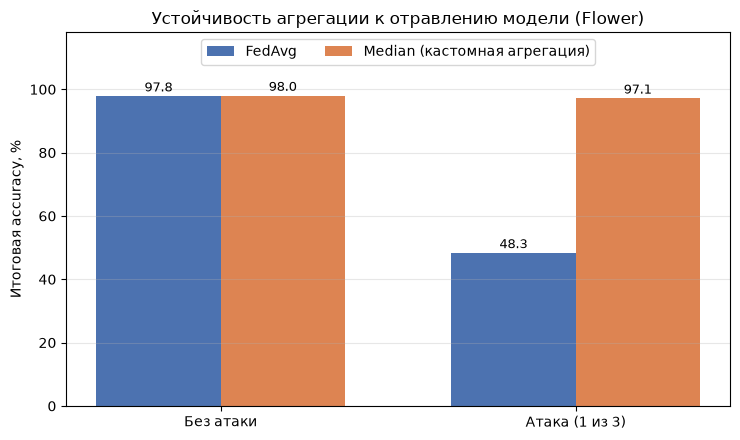

График обновлён: flower_aggregation_poison.png


In [26]:
import numpy as np

conditions = ["Без атаки", "Атака (1 из 3)"]
fedavg = [agg_results["FedAvg, без атаки"][-1], agg_results["FedAvg, атака"][-1]]
median = [agg_results["Median, без атаки"][-1], agg_results["Median, атака"][-1]]

x = np.arange(len(conditions)); w = 0.35
plt.figure(figsize=(7.5, 4.5))
b1 = plt.bar(x - w/2, fedavg, w, label="FedAvg", color="#4C72B0")
b2 = plt.bar(x + w/2, median, w, label="Median (кастомная агрегация)", color="#DD8452")
plt.xticks(x, conditions)
plt.ylabel("Итоговая accuracy, %"); plt.ylim(0, 118)
plt.title("Устойчивость агрегации к отравлению модели (Flower)")
for bars in (b1, b2):
    for b in bars:
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
                 f"{b.get_height():.1f}", ha="center", fontsize=9)
plt.legend(loc="upper center", ncol=2, frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("flower_aggregation_poison.png", dpi=120, bbox_inches="tight")
plt.show()
print("График обновлён: flower_aggregation_poison.png")